# Paper Figure: Original-Answer Win Rates

This notebook reproduces the pairwise win-rate logic from `evaluations/biomni-base/results_analysis.ipynb`, but combines `chatbs-base` and `biomni-base` in a single publication-style graph. It intentionally uses only the `answer_winrate-original` outputs for both datasets.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / "evaluations").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing evaluations/ and pyproject.toml")


REPO_ROOT = find_repo_root()
EVALUATIONS_DIR = REPO_ROOT / "evaluations"
FIGURE_DIR = REPO_ROOT / "paper_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = [
    ("chatbs-base", "ChatBS"),
    ("biomni-base", "Biomni"),
]
WINRATE_DIRNAME = "answer_winrate-original"

METHOD_ORDER = [
    "llmbased",
    "vectorsimilarity",
    "grasp",
    "hipporag",
    "hypergraphrag",
]
METHOD_LABELS = {
    "llmbased": "GWB",
    "vectorsimilarity": "VSB",
    "hipporag": "HippoRAG",
    "hypergraphrag": "HyperGRAG",
    "grasp": "GRASP",
    "ours": "Ours",
    "LWE": "Ours",
}

REPO_ROOT

PosixPath('/home/desild/work/research/LLM-Workflow-Explorer')

## Load Pairwise Win-Rate Data

The existing evaluation notebooks compute pairwise summaries from `pairwise_answer_winrate.csv`, where ties count as half a win. The helper below keeps that same convention and canonicalizes raw `LWE` labels to the internal `ours` key before computing per-baseline win rates.

In [2]:
def read_csv_or_empty(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def canonicalize_pairwise_methods(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    if pairwise_df.empty:
        return pairwise_df

    df = pairwise_df.copy()
    original_a = df.get("method_a", pd.Series(index=df.index, dtype=object)).astype(str)
    original_b = df.get("method_b", pd.Series(index=df.index, dtype=object)).astype(str)

    if "method_a_key" in df.columns:
        df["method_a"] = df["method_a_key"].fillna(df["method_a"])
    if "method_b_key" in df.columns:
        df["method_b"] = df["method_b_key"].fillna(df["method_b"])

    df["method_a"] = df["method_a"].replace({"LWE": "ours"})
    df["method_b"] = df["method_b"].replace({"LWE": "ours"})

    if "winning_method" in df.columns:
        winning = df["winning_method"].copy()
        winning = winning.mask(winning.astype(str).eq(original_a), df["method_a"])
        winning = winning.mask(winning.astype(str).eq(original_b), df["method_b"])
        winning = winning.replace({"LWE": "ours"})
        df["winning_method"] = winning

    return df


def pairwise_ours_summary(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    columns = [
        "opponent",
        "comparisons",
        "ours_wins",
        "opponent_wins",
        "ties",
        "ours_winrate",
        "opponent_winrate",
    ]
    if pairwise_df.empty:
        return pd.DataFrame(columns=columns)

    ours_rows = pairwise_df[pairwise_df["method_a"].eq("ours") | pairwise_df["method_b"].eq("ours")].copy()
    if ours_rows.empty:
        return pd.DataFrame(columns=columns)

    opponents = ours_rows.apply(
        lambda row: row["method_b"] if row["method_a"] == "ours" else row["method_a"],
        axis=1,
    )

    rows = []
    for opponent in METHOD_ORDER:
        subset = ours_rows[opponents.eq(opponent)]
        if subset.empty:
            continue

        total = len(subset)
        ours_wins = subset["winning_method"].eq("ours").sum()
        opponent_wins = subset["winning_method"].eq(opponent).sum()
        ties = total - ours_wins - opponent_wins
        rows.append({
            "opponent": opponent,
            "comparisons": int(total),
            "ours_wins": int(ours_wins),
            "opponent_wins": int(opponent_wins),
            "ties": int(ties),
            "ours_winrate": (ours_wins + 0.5 * ties) / total,
            "opponent_winrate": (opponent_wins + 0.5 * ties) / total,
        })

    return pd.DataFrame(rows, columns=columns)


def load_dataset_winrates(dataset_id: str, dataset_label: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    winrate_dir = EVALUATIONS_DIR / dataset_id / "analysis" / WINRATE_DIRNAME
    pairwise_path = winrate_dir / "pairwise_answer_winrate.csv"
    summary_path = winrate_dir / "answer_winrate_summary.csv"

    pairwise_df = canonicalize_pairwise_methods(read_csv_or_empty(pairwise_path))
    if pairwise_df.empty:
        raise FileNotFoundError(f"Missing or empty pairwise win-rate file: {pairwise_path}")

    method_summary = read_csv_or_empty(summary_path)
    summary = pairwise_ours_summary(pairwise_df)
    summary.insert(0, "dataset_id", dataset_id)
    summary.insert(1, "dataset", dataset_label)
    summary.insert(2, "answer_variant", "Original answer")
    summary["opponent_label"] = summary["opponent"].map(METHOD_LABELS).fillna(summary["opponent"])
    summary["ours_winrate_pct"] = summary["ours_winrate"] * 100

    return summary, pairwise_df, method_summary

In [3]:
summary_frames = []
pairwise_frames = {}
method_summary_frames = {}

for dataset_id, dataset_label in DATASETS:
    summary, pairwise_df, method_summary = load_dataset_winrates(dataset_id, dataset_label)
    summary_frames.append(summary)
    pairwise_frames[dataset_id] = pairwise_df
    method_summary_frames[dataset_id] = method_summary

winrate_summary = pd.concat(summary_frames, ignore_index=True)
winrate_summary["opponent"] = pd.Categorical(winrate_summary["opponent"], categories=METHOD_ORDER, ordered=True)
winrate_summary["dataset"] = pd.Categorical(
    winrate_summary["dataset"],
    categories=[label for _dataset_id, label in DATASETS],
    ordered=True,
)
winrate_summary = winrate_summary.sort_values(["opponent", "dataset"]).reset_index(drop=True)

summary_csv = FIGURE_DIR / "original_answer_winrates_chatbs_biomni.csv"
winrate_summary.to_csv(summary_csv, index=False)

print(f"Wrote {summary_csv.relative_to(REPO_ROOT)}")
winrate_summary[[
    "dataset",
    "opponent_label",
    "comparisons",
    "ours_wins",
    "opponent_wins",
    "ties",
    "ours_winrate_pct",
]]

Wrote paper_figures/original_answer_winrates_chatbs_biomni.csv


,dataset,opponent_label,comparisons,ours_wins,opponent_wins,ties,ours_winrate_pct
0,ChatBS,GWB,103,94,9,0,91.262136
1,Biomni,GWB,106,104,2,0,98.113208
2,ChatBS,VSB,103,90,11,2,88.349515
3,Biomni,VSB,106,101,5,0,95.283019
4,ChatBS,GRASP,103,91,12,0,88.349515
5,Biomni,GRASP,106,103,3,0,97.169811
6,ChatBS,HippoRAG,103,98,5,0,95.145631
7,Biomni,HippoRAG,106,96,10,0,90.566038
8,ChatBS,HyperGRAG,103,64,39,0,62.135922
9,Biomni,HyperGRAG,106,57,49,0,53.773585


## LaTeX Table

This table uses the same baseline ordering and labels as the figure. Values are Ours' pairwise win rate over each baseline in percent, with ties counted as half wins.

In [4]:
table_df = winrate_summary.pivot_table(
    index="opponent_label",
    columns="dataset",
    values="ours_winrate_pct",
    aggfunc="first",
    observed=False,
)

label_order = [METHOD_LABELS[method] for method in METHOD_ORDER]
dataset_order = [label for _dataset_id, label in DATASETS]
table_df = table_df.reindex(index=label_order, columns=dataset_order).round(1)
table_df = table_df.rename_axis("Baseline").reset_index()

table_csv = FIGURE_DIR / "original_answer_winrates_chatbs_biomni_table.csv"
table_tex = FIGURE_DIR / "original_answer_winrates_chatbs_biomni_table.tex"
table_df.to_csv(table_csv, index=False)

latex_table = table_df.to_latex(
    index=False,
    column_format="lrr",
    float_format=lambda value: f"{value:.1f}",
    caption=(
        "Pairwise original-answer win rates of Ours against each baseline on "
        "the ChatBS and Biomni evaluations. Ties count as half wins."
    ),
    label="tab:original-answer-baseline-winrates",
)
table_tex.write_text(latex_table)

print(f"Wrote {table_csv.relative_to(REPO_ROOT)}")
print(f"Wrote {table_tex.relative_to(REPO_ROOT)}")
table_df

Wrote paper_figures/original_answer_winrates_chatbs_biomni_table.csv
Wrote paper_figures/original_answer_winrates_chatbs_biomni_table.tex


dataset,Baseline,ChatBS,Biomni
0,GWB,91.3,98.1
1,VSB,88.3,95.3
2,GRASP,88.3,97.2
3,HippoRAG,95.1,90.6
4,HyperGRAG,62.1,53.8


## Paper Figure

The plot uses a colorblind-safe palette, embedded TrueType fonts in vector exports, a light grid for reading percentages, and a 50% reference line for parity.

Wrote paper_figures/original_answer_winrates_chatbs_biomni.pdf
Wrote paper_figures/original_answer_winrates_chatbs_biomni.png


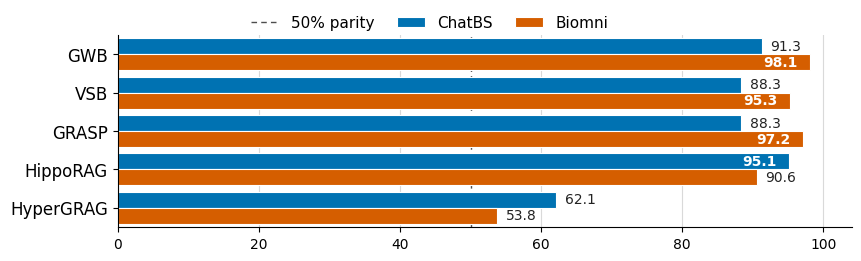

In [5]:
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

DATASET_COLORS = {
    "ChatBS": "#0072B2",
    "Biomni": "#D55E00",
}

# Font-size controls for the paper figure.
X_TICK_FONT_SIZE = 10
Y_TICK_FONT_SIZE = 12
AXIS_LABEL_FONT_SIZE = 11
LEGEND_FONT_SIZE = 11
BAR_VALUE_FONT_SIZE = 10

X_AXIS_LABEL = None  # Set to "Win rate of Ours over baseline (%)" to show an x-axis label.
Y_AXIS_LABEL = None

plot_df = winrate_summary.copy()
baseline_order = [method for method in METHOD_ORDER if method in plot_df["opponent"].astype(str).unique()]
dataset_order = [label for _dataset_id, label in DATASETS]

fig, ax = plt.subplots(figsize=(8.5, 2.5), constrained_layout=True)
row_spacing = 0.90
y_positions = np.arange(len(baseline_order)) * row_spacing
bar_height = 0.375
bar_gap = 0.0005

for index, dataset_label in enumerate(dataset_order):
    offset = (index - (len(dataset_order) - 1) / 2) * (bar_height + bar_gap)
    dataset_df = plot_df[plot_df["dataset"].eq(dataset_label)].set_index("opponent")
    values = [dataset_df.loc[method, "ours_winrate_pct"] if method in dataset_df.index else np.nan for method in baseline_order]

    bars = ax.barh(
        y_positions + offset,
        values,
        height=bar_height,
        color=DATASET_COLORS[dataset_label],
        edgecolor="white",
        linewidth=0.8,
        label=dataset_label,
    )

    for bar, value in zip(bars, values):
        if np.isnan(value):
            continue
        if value >= 93:
            ax.text(
                value - 1.8,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}",
                va="center",
                ha="right",
                color="white",
                fontsize=BAR_VALUE_FONT_SIZE,
                fontweight="bold",
            )
        else:
            ax.text(
                value + 1.2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}",
                va="center",
                ha="left",
                color="#222222",
                fontsize=BAR_VALUE_FONT_SIZE,
            )

parity_line = ax.axvline(
    50,
    color="#4d4d4d",
    linestyle=(0, (4, 3)),
    linewidth=1.0,
    zorder=0,
    label="50% parity",
)

ax.set_yticks(y_positions)
ax.set_yticklabels([METHOD_LABELS.get(method, method) for method in baseline_order])
ax.tick_params(axis="x", labelsize=X_TICK_FONT_SIZE)
ax.tick_params(axis="y", labelsize=Y_TICK_FONT_SIZE)
ax.invert_yaxis()
ax.set_xlim(0, 104)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xlabel(X_AXIS_LABEL or "", fontsize=AXIS_LABEL_FONT_SIZE)
ax.set_ylabel(Y_AXIS_LABEL or "", fontsize=AXIS_LABEL_FONT_SIZE)
ax.xaxis.grid(True, color="#d9d9d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.margins(y=0.02)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.425, 0.95),
    ncols=3,
    columnspacing=1.5,
    handlelength=1.8,
    fontsize=LEGEND_FONT_SIZE,
)

figure_pdf = FIGURE_DIR / "original_answer_winrates_chatbs_biomni.pdf"
figure_png = FIGURE_DIR / "original_answer_winrates_chatbs_biomni.png"
fig.savefig(figure_pdf)
fig.savefig(figure_png, dpi=2000)

print(f"Wrote {figure_pdf.relative_to(REPO_ROOT)}")
print(f"Wrote {figure_png.relative_to(REPO_ROOT)}")

## Optional: Dataset-Level Aggregate

This final cell reports the aggregate `Ours` win rate from each dataset's `answer_winrate_summary.csv`, which is useful for captions or text callouts but is not the value plotted per baseline above.

In [6]:
aggregate_rows = []
for dataset_id, dataset_label in DATASETS:
    summary = method_summary_frames[dataset_id].copy()
    if summary.empty:
        continue
    summary["method"] = summary["method"].replace({"LWE": "ours"})
    lwe_row = summary[summary["method"].eq("ours")]
    if lwe_row.empty:
        continue
    row = lwe_row.iloc[0].to_dict()
    row["dataset_id"] = dataset_id
    row["dataset"] = dataset_label
    row["winrate_pct"] = row["winrate"] * 100
    aggregate_rows.append(row)

aggregate_summary = pd.DataFrame(aggregate_rows)
aggregate_summary[["dataset", "comparisons", "wins", "losses", "ties", "winrate_pct"]]

,dataset,comparisons,wins,losses,ties,winrate_pct
0,ChatBS,618,494,122,2,80.097087
1,Biomni,636,556,80,0,87.421384
